In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import timm
import pennylane as qml
from torch.utils.data import Dataset, DataLoader, TensorDataset
from tqdm import tqdm
from pathlib import Path

class CONFIG:
    TRAIN_PATH = "C:/Users/wikto/Desktop/Google summer of code/dataset/train"
    VAL_PATH = "C:/Users/wikto/Desktop/Google summer of code/dataset/val"
    TRAIN_FEATS = "train_resnet_features.npz"
    VAL_FEATS = "val_resnet_features.npz"
    
    BATCH_SIZE = 32
    LEARNING_RATE = 1e-3 
    EPOCHS = 30
    DROPOUT = 0.33
    DEVICE = "cpu"
    
    N_QUBITS = 12 
    N_LAYERS = 7
    RANDOM_SEED = 58


torch.manual_seed(CONFIG.RANDOM_SEED)
np.random.seed(CONFIG.RANDOM_SEED)

dev = qml.device("lightning.qubit", wires=CONFIG.N_QUBITS)
@qml.qnode(dev, interface="torch")
def quantum_net(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(CONFIG.N_QUBITS))
    qml.StronglyEntanglingLayers(weights, wires=range(CONFIG.N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(CONFIG.N_QUBITS)]

class GSoCHybridQuantumModel(nn.Module):
    def __init__(self, n_classes, num_ftrs=2048):
        super().__init__()
        
        self.classical_head = nn.Sequential(
            nn.Linear(num_ftrs, 1024),
            nn.ReLU(),
            nn.BatchNorm1d(1024),
            nn.Dropout(p=CONFIG.DROPOUT),
            nn.Linear(1024, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64)
        )
        
        self.to_qubits = nn.Linear(64, CONFIG.N_QUBITS)
        
        weight_shapes = {"weights": (CONFIG.N_LAYERS, CONFIG.N_QUBITS, 3)}
        self.q_layer = qml.qnn.TorchLayer(quantum_net, weight_shapes)
        nn.init.normal_(self.q_layer.weights, std=0.1) 
        
        self.post_quantum = nn.Linear(CONFIG.N_QUBITS, n_classes)

    def forward(self, x):
        x = self.classical_head(x)
        x = torch.tanh(self.to_qubits(x)) * (np.pi / 2.0) 
        x = self.q_layer(x)
        return self.post_quantum(x)

def run_feature_extraction(path, output_file, class_to_idx):
    if os.path.exists(output_file):
        print(f"Already exists, skiping")
        return

    print(f"Resnet extra")
    model = timm.create_model('resnet50', pretrained=True, in_chans=1, num_classes=0).to(CONFIG.DEVICE).eval()
    
    img_paths = []
    for cls in sorted(os.listdir(path)):
        cls_path = Path(path) / cls
        if cls_path.is_dir():
            img_paths.extend(list(cls_path.glob("*.npy")))
    
    all_feats, all_labels = [], []
    with torch.no_grad():
        for p in tqdm(img_paths):
            img = np.load(p)
            if len(img.shape) == 2: 
                img = np.expand_dims(img, axis=0)
            img_t = torch.from_numpy(img).unsqueeze(0).float().to(CONFIG.DEVICE)
            feat = model(img_t)
            all_feats.append(feat.cpu().numpy())
            all_labels.append(class_to_idx[p.parent.name])
            
    np.savez(output_file, x=np.vstack(all_feats), y=np.array(all_labels))

def main():
    classes = sorted([d for d in os.listdir(CONFIG.TRAIN_PATH) 
                     if os.path.isdir(os.path.join(CONFIG.TRAIN_PATH, d)) 
                     and not d.startswith('.')])
    
    class_to_idx = {cls: i for i, cls in enumerate(classes)}
    num_detected_classes = len(classes)

    
    run_feature_extraction(CONFIG.TRAIN_PATH, CONFIG.TRAIN_FEATS, class_to_idx)
    run_feature_extraction(CONFIG.VAL_PATH, CONFIG.VAL_FEATS, class_to_idx)

    train_data = np.load(CONFIG.TRAIN_FEATS)
    val_data = np.load(CONFIG.VAL_FEATS)
    
    unique_labels = np.unique(train_data['y'])    
    actual_n_classes = int(max(unique_labels) + 1)

    if actual_n_classes != num_detected_classes:
        final_n_classes = max(actual_n_classes, num_detected_classes)
    else:
        final_n_classes = num_detected_classes

    train_loader = DataLoader(
        TensorDataset(torch.from_numpy(train_data['x']).float(), torch.from_numpy(train_data['y']).long()), 
        batch_size=CONFIG.BATCH_SIZE, shuffle=True
    )
    
    val_loader = DataLoader(
        TensorDataset(torch.from_numpy(val_data['x']).float(), torch.from_numpy(val_data['y']).long()), 
        batch_size=CONFIG.BATCH_SIZE, shuffle=False
    )

    model = GSoCHybridQuantumModel(n_classes=final_n_classes).to(CONFIG.DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG.LEARNING_RATE)
    criterion = nn.CrossEntropyLoss()
    
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=3, factor=0.5)
    best_v_acc = 0
    for epoch in range(CONFIG.EPOCHS):
        model.train()
        correct, total, train_loss = 0, 0, 0
        for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):
            x, y = x.to(CONFIG.DEVICE), y.to(CONFIG.DEVICE)
            
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, pred = out.max(1)
            total += y.size(0)
            correct += pred.eq(y).sum().item()
        
        model.eval()
        v_correct, v_total = 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(CONFIG.DEVICE), y.to(CONFIG.DEVICE)
                v_out = model(x)
                _, v_pred = v_out.max(1)
                v_total += y.size(0)
                v_correct += v_pred.eq(y).sum().item()

        t_acc = 100 * correct / total
        v_acc = 100 * v_correct / v_total
        
        print(f"Loss: {train_loss/len(train_loader)} | Train Acc: {t_acc}% | Val Acc: {v_acc}%")

        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(v_acc)
        new_lr = optimizer.param_groups[0]['lr']
        if old_lr != new_lr:
            print(f"Lr changed {old_lr} - {new_lr}")

        if v_acc > best_v_acc:
            best_v_acc = v_acc
            torch.save(model.state_dict(), "models/quantum_best.pth")
            print("new best")


In [5]:
if __name__ == "__main__":
    main()

Detected 3 classes: ['no', 'sphere', 'vort']
Mapping: {'no': 0, 'sphere': 1, 'vort': 2}
File train_resnet_features.npz already exists. Skipping extraction.
File val_resnet_features.npz already exists. Skipping extraction.
Unique labels found in training data: [1 2 3]


Epoch 1 Training:   0%|          | 1/938 [00:02<33:20,  2.13s/it]


KeyboardInterrupt: 

In [ ]:
import torch.nn.functional as F

val_data = np.load(CONFIG.VAL_FEATS)
val_loader = DataLoader(
    TensorDataset(torch.from_numpy(val_data['x']).float(), torch.from_numpy(val_data['y']).long()), 
    batch_size=CONFIG.BATCH_SIZE, shuffle=False
)

def get_predictions(model_path, data_loader):
    model = GSoCHybridQuantumModel(n_classes=4).to(CONFIG.DEVICE) # 4 classes to fix previous shift

    model.load_state_dict(torch.load(model_path, map_location=CONFIG.DEVICE))
    model.eval()
    
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for features, labels in tqdm(data_loader, desc="Predicting"):
            features = features.to(CONFIG.DEVICE)
            
            outputs = model(features)
            probs = F.softmax(outputs, dim=1)
            
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
    return np.array(all_labels), np.array(all_probs)

y_true, y_probs = get_predictions(
    model_path='models/quantum_best.pth', 
    data_loader=val_loader,
)

y_pred = np.argmax(y_probs, axis=1)

Running inference on cpu...


Predicting: 100%|██████████| 235/235 [06:05<00:00,  1.55s/it]


              precision    recall  f1-score   support

          no       0.56      0.79      0.66      2500
      sphere       0.55      0.44      0.49      2500
        vort       0.55      0.44      0.49      2500

    accuracy                           0.56      7500
   macro avg       0.55      0.56      0.54      7500
weighted avg       0.55      0.56      0.54      7500

AUC for no: 0.82879368
AUC for sphere: 0.71351528
AUC for vort: 0.70844796


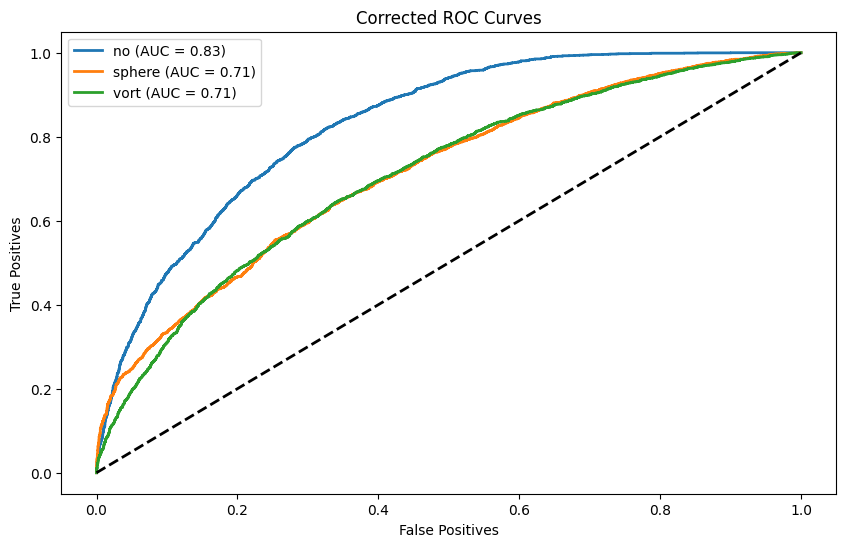

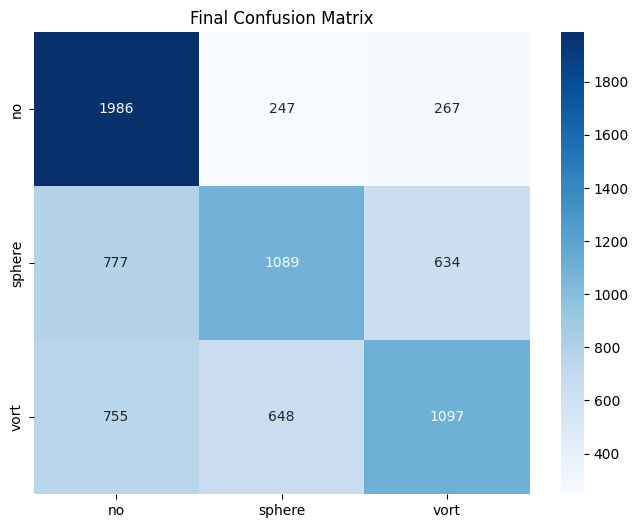

In [24]:
from sklearn.metrics import classification_report, roc_curve, auc, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# fix for a previously made shift
y_true_corrected = y_true - 1
y_pred_corrected = y_pred - 1
y_probs_corrected = y_probs[:, 1:] 
actual_classes = ["no", "sphere", "vort"]

print(classification_report(y_true_corrected, y_pred_corrected, target_names=actual_classes))

plt.figure(figsize=(10, 6))
y_true_onehot = np.eye(len(actual_classes))[y_true_corrected]

for i in range(len(actual_classes)):
    fpr, tpr, _ = roc_curve(y_true_onehot[:, i], y_probs_corrected[:, i])
    plt.plot(fpr, tpr, lw=2, label=f'{actual_classes[i]} (AUC = {auc(fpr, tpr):.2f})')

y_probs_actual = y_probs[:, 1:]
auc_per_class = roc_auc_score(y_true_onehot, y_probs_actual, average=None)
for i, class_name in enumerate(actual_classes):
    print(f"AUC for {class_name}: {auc_per_class[i]}")

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title('Corrected ROC Curves')
plt.xlabel('False Positives')
plt.ylabel('True Positives')
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true_corrected, y_pred_corrected)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=actual_classes, yticklabels=actual_classes)
plt.title('Final Confusion Matrix')
plt.show()